**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update the portfolio index link to your own work once completed!

# Predicting Titanic Survivors Using Neural Networks

## Objective
Build a neural network model that predicts survivors of the Titanic voyage using data from the Titanic data set. Explore feature engineering, train a neural network and compare to a neural network trained on the origional features.


## 1. Data

In [65]:
import pandas as pd
import numpy as np
import keras
from keras import layers
from itertools import product
from sklearn.model_selection import KFold
import tensorflow as tf
import matplotlib as plt
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
import sys
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, log_loss, accuracy_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, brier_score_loss

In [66]:
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from typing import List, Tuple, Optional, Dict, Any

In [67]:
import ssl, certifi
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

In [68]:
# Load the Titanic data set.
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)

In [69]:
# look at the first few rows
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


- PassengerID likely not useful.
- Survived will be our target.
- Name is liekly not useful.

In [70]:
titanic_df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [71]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Missing etries from age, cabin and embarked. 

We will explore the missing data relationships closely.

In [72]:
# Create X and target set
y_data = titanic_df["Survived"]
X_data = titanic_df.drop(columns=["PassengerId", "Survived", "Name"])


In [73]:
X_data.head()

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,female,35.0,1,0,113803,53.1000,C123,S
4,3,male,35.0,0,0,373450,8.0500,NaN,S


## 2. Missingness Analysis

In [74]:
# Missingness Analysis
# ----------------------------------------
# Utility: missingness indicators
# ----------------------------------------
def add_missing_flags(df, cols=("Age", "Cabin", "Embarked")):
    out = df.copy()
    for c in cols:
        out[f"{c}_missing"] = out[c].isna().astype(int)
    return out

# ----------------------------------------
# Quick missingness dependency checks 
#   (Is missingness related to other vars?)
# ----------------------------------------
def missingness_report(df, target_col, by_cols=("Pclass", "Sex", "Embarked")):
    """
    Shows missing rate of target_col conditioned on by_cols.
    """
    m = df[target_col].isna().astype(int)  # 0 = not missing, 1 = missing
    rep = {}

    for c in by_cols:
        if c not in df.columns:
            continue

        tab = pd.crosstab(df[c], m, normalize="index")

        # Ensure both columns (0 and 1) exist
        if 0 not in tab.columns:
            tab[0] = 0.0
        if 1 not in tab.columns:
            tab[1] = 0.0

        tab = tab[[0, 1]]
        tab.columns = ["not_missing", "missing"]

        rep[c] = tab.sort_values("missing", ascending=False)

    return rep

# ----------------------------------------
# Categorical | Categorical association
#   (Chi-square + Cramér's V)
# ----------------------------------------
def cramers_v(x, y):
    """
    Cramér's V in [0,1], higher = stronger association.
    """
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, k = ct.shape
    # bias correction 
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

def cat_cat_association(df, target_cat, candidate_cats):
    rows = []
    for c in candidate_cats:
        if c not in df.columns:
            continue
        tmp = df[[target_cat, c]].dropna()
        if tmp.empty:
            continue
        v = cramers_v(tmp[target_cat], tmp[c])
        rows.append((c, v, len(tmp)))
    out = pd.DataFrame(rows, columns=["feature", "cramers_v", "n"])
    return out.sort_values("cramers_v", ascending=False)

# ----------------------------------------
# Categorical | Numeric relationship
#   (Group stats + ANOVA-style effect size: eta^2)
# ----------------------------------------
def eta_squared(df, group_col, y_col):
    """
    eta^2 = SS_between / SS_total. In [0,1], higher = stronger group effect.
    """
    tmp = df[[group_col, y_col]].dropna()
    if tmp.empty:
        return np.nan
    y = tmp[y_col].to_numpy()
    grand_mean = y.mean()
    ss_total = ((y - grand_mean) ** 2).sum()

    ss_between = 0.0
    for g, grp in tmp.groupby(group_col):
        yg = grp[y_col].to_numpy()
        ss_between += len(yg) * (yg.mean() - grand_mean) ** 2

    return (ss_between / ss_total) if ss_total > 0 else 0.0

def cat_to_num_summary(df, y_col, candidate_cats):
    rows = []
    for c in candidate_cats:
        if c not in df.columns:
            continue
        e2 = eta_squared(df, c, y_col)
        n = df[[c, y_col]].dropna().shape[0]
        rows.append((c, e2, n))
    out = pd.DataFrame(rows, columns=["feature", "eta_squared", "n"])
    return out.sort_values("eta_squared", ascending=False)

def group_describe(df, y_col, group_cols):
    """
    Detailed group stats for Age (or Fare) by some categorical grouping.
    """
    tmp = df[group_cols + [y_col]].dropna()
    if tmp.empty:
        return pd.DataFrame()
    return tmp.groupby(group_cols)[y_col].describe().sort_values("count", ascending=False)

# ----------------------------------------
# Numeric | Numeric correlation
# ----------------------------------------
def num_num_corr(df, y_col, candidate_nums, method="spearman"):
    tmp = df[candidate_nums + [y_col]].dropna()
    if tmp.empty:
        return pd.Series(dtype=float)
    corrs = tmp[candidate_nums].corrwith(tmp[y_col], method=method)
    return corrs.sort_values(key=lambda s: s.abs(), ascending=False)

# ----------------------------------------
# Mutual information 
#   - Embarked/CabinKnown as classification targets
#   - Age as regression target
# ----------------------------------------
def mutual_info_for_embarked(df, feature_cols):
    """
    Returns MI(feature; Embarked) using:
      - numeric filled with median
      - categorical filled with 'Missing' and ordinal-encoded via pandas codes
    """
    tmp = df[feature_cols + ["Embarked"]].copy()
    tmp = tmp.dropna(subset=["Embarked"])
    y = tmp["Embarked"].astype("category").cat.codes

    X = tmp[feature_cols].copy()
    for c in feature_cols:
        if pd.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].fillna(X[c].median())
        else:
            X[c] = X[c].fillna("Missing").astype("category").cat.codes

    mi = mutual_info_classif(X.to_numpy(), y.to_numpy(), discrete_features="auto", random_state=42)
    out = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
    return out

def mutual_info_for_age(df, feature_cols):
    """
    MI(feature; Age) treating Age as continuous target.
    """
    tmp = df[feature_cols + ["Age"]].copy()
    tmp = tmp.dropna(subset=["Age"])
    y = tmp["Age"].to_numpy()

    X = tmp[feature_cols].copy()
    for c in feature_cols:
        if pd.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].fillna(X[c].median())
        else:
            X[c] = X[c].fillna("Missing").astype("category").cat.codes

    mi = mutual_info_regression(X.to_numpy(), y, discrete_features="auto", random_state=42)
    out = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
    return out

# ----------------------------------------
# Run predictor analysis
# ----------------------------------------
def run_predictor_analysis(df):
    df = df.copy()
    
    # Add missing flags
    df = add_missing_flags(df)

    # Basic engineered helpers that are useful for investigating Cabin
    df["CabinKnown"] = df["Cabin"].notna().astype(int)
    df["Deck"] = df["Cabin"].astype(str).str[0].where(df["Cabin"].notna(), "Unknown")

    # Candidate sets (adjust if your df differs)
    cat_cols = [c for c in ["Pclass", "Sex", "Embarked", "Deck"] if c in df.columns]
    num_cols = [c for c in ["Age", "SibSp", "Parch", "Fare"] if c in df.columns]

    print("\n==============================")
    print("A) Missingness dependency")
    print("==============================")
    for tgt in ["Age", "Cabin", "Embarked"]:
        if tgt not in df.columns:
            continue
        reps = missingness_report(df, tgt, by_cols=("Pclass", "Sex", "Embarked"))
        print(f"\n--- Missingness of {tgt} ---")
        for k, tab in reps.items():
            print(f"\nMissing rate by {k}:\n{tab}")

    print("\n==============================")
    print("B) What predicts Embarked?")
    print("==============================")
    # cat-cat association
    emb_cat_candidates = [c for c in ["Pclass", "Sex", "Deck"] if c in df.columns]
    if "Embarked" in df.columns and emb_cat_candidates:
        print("\nCramér's V (categorical associations):")
        print(cat_cat_association(df, "Embarked", emb_cat_candidates))

    # cat->num for Fare/Embarked often informative
    if "Fare" in df.columns and "Embarked" in df.columns:
        print("\nGroup stats for Fare by Embarked:")
        print(df.groupby("Embarked")["Fare"].describe())

    # mutual info for Embarked
    feat_cols_emb = [c for c in ["Pclass", "Sex", "SibSp", "Parch", "Fare", "CabinKnown", "Deck"] if c in df.columns]
    if "Embarked" in df.columns and feat_cols_emb:
        print("\nMutual information with Embarked:")
        print(mutual_info_for_embarked(df, feat_cols_emb))

    print("\n==============================")
    print("C) What predicts Age?")
    print("==============================")
    age_cat_candidates = [c for c in ["Pclass", "Sex", "Embarked", "Deck"] if c in df.columns]
    if "Age" in df.columns and age_cat_candidates:
        print("\nEta^2 (categorical -> Age group effect):")
        print(cat_to_num_summary(df, "Age", age_cat_candidates))

        print("\nAge by (Sex, Pclass) group stats:")
        if set(["Sex", "Pclass"]).issubset(df.columns):
            print(group_describe(df, "Age", ["Sex", "Pclass"]).head(20))

    age_num_candidates = [c for c in ["SibSp", "Parch", "Fare"] if c in df.columns]
    if "Age" in df.columns and age_num_candidates:
        print("\nSpearman correlation with Age (numeric -> Age):")
        print(num_num_corr(df, "Age", age_num_candidates, method="spearman"))

    feat_cols_age = [c for c in ["Pclass", "Sex", "SibSp", "Parch", "Fare", "Embarked", "CabinKnown", "Deck"] if c in df.columns]
    if "Age" in df.columns and feat_cols_age:
        print("\nMutual information with Age:")
        print(mutual_info_for_age(df, feat_cols_age))

    print("\n==============================")
    print("D) What predicts CabinKnown / Deck?")
    print("==============================")
    # CabinKnown is easier/more useful than full Cabin
    if "CabinKnown" in df.columns:
        feat_cols_ck = [c for c in ["Pclass", "Sex", "Embarked", "Fare", "SibSp", "Parch"] if c in df.columns]
        tmp = df[feat_cols_ck + ["CabinKnown"]].dropna(subset=["CabinKnown"])
        y = tmp["CabinKnown"].astype(int)

        X = tmp[feat_cols_ck].copy()
        for c in feat_cols_ck:
            if pd.api.types.is_numeric_dtype(X[c]):
                X[c] = X[c].fillna(X[c].median())
            else:
                X[c] = X[c].fillna("Missing").astype("category").cat.codes

        mi = mutual_info_classif(X.to_numpy(), y.to_numpy(), discrete_features="auto", random_state=42)
        mi_s = pd.Series(mi, index=feat_cols_ck).sort_values(ascending=False)
        print("\nMutual information with CabinKnown:")
        print(mi_s)

        if "Fare" in df.columns:
            print("\nFare by CabinKnown:")
            print(df.groupby("CabinKnown")["Fare"].describe())

    return df 

## 2. Feature Engineering

In [75]:
# Physics-informed feature block
# ---------------------------
def add_physics_informed_features(
    X_eng: pd.DataFrame,
    *,
    eps: float = 1e-6,
    age_col: str = "Age",
    fare_col: str = "Fare",
    sibsp_col: str = "SibSp",
    parch_col: str = "Parch",
    pclass_col: str = "Pclass",
    sex_col: str = "Sex",
    embarked_col: str = "Embarked",
    cabin_col: str = "Cabin",
    age_missing_col: str = "Age_missing",
    cabin_missing_col: str = "Cabin_missing",
    embarked_missing_col: str = "Embarked_missing",
    use_deck: bool = True,
):
    """
    Adds:
      - FamilySize, FarePerPerson, LogFare, LogFarePerPerson
      - CabinKnown from missing flag (if not already)
      - Deck (Unknown if cabin missing)
      - AgeImputeStd: group-wise std for Age to carry "error bars"
      - AgeImputed: group-wise median imputation 
    """
    df = enriched_df.copy()

    # --- dimensionless / normalized-ish groups ---
    df["FamilySize"] = df[sibsp_col].fillna(0) + df[parch_col].fillna(0) + 1
    df["FarePerPerson"] = df[fare_col].fillna(0) / np.maximum(df["FamilySize"], 1)
    df["LogFare"] = np.log(df[fare_col].fillna(0) + eps)
    df["LogFarePerPerson"] = np.log(df["FarePerPerson"] + eps)

    # --- sensor-status channels (missingness flags) ---
    # If you already have these columns, this just keeps them.
    '''for mcol in [age_missing_col, cabin_missing_col, embarked_missing_col]:
        if mcol not in df.columns:
            # infer if absent
            base = mcol.replace("_missing", "")
            if base in df.columns:
                df[mcol] = df[base].isna().astype(int)
            else:
                df[mcol] = 0'''

    # CabinKnown is a useful socioeconomic "measurement present" flag
    '''if "CabinKnown" not in df.columns:
        df["CabinKnown"] = 1 - df[cabin_missing_col].astype(int)'''

    # Deck is useful; extract deck or Unknown
    '''if use_deck:
        if "Deck" not in df.columns:
            if cabin_col in df.columns:
                df["Deck"] = df[cabin_col].astype(str).str[0].where(df[cabin_col].notna(), "Unknown")
            else:
                df["Deck"] = np.where(df["CabinKnown"] == 1, "Known", "Unknown")'''

    # --- Age: impute median by group, and carry group std as "uncertainty" ---
    group_cols = []
    for c in [sex_col, pclass_col]:
        if c in df.columns:
            group_cols.append(c)
    if use_deck and "Deck" in df.columns:
        group_cols.append("Deck")

    # Compute group stats on known ages only
    if age_col in df.columns and group_cols:
        known = df[df[age_missing_col] == 0].copy()
        if not known.empty:
            grp = known.groupby(group_cols)[age_col]
            med = grp.median()
            std = grp.std()

            # Map med/std back onto all rows
            idx = pd.MultiIndex.from_frame(df[group_cols])
            df["AgeImputeMedian"] = med.reindex(idx).to_numpy()
            df["AgeImputeStd"] = std.reindex(idx).to_numpy()

            # Fallbacks
            global_med = known[age_col].median()
            global_std = known[age_col].std()

            df["AgeImputeMedian"] = df["AgeImputeMedian"].fillna(global_med)
            df["AgeImputeStd"] = df["AgeImputeStd"].fillna(global_std if pd.notna(global_std) else 0.0)

            # Create an imputed age column (leave original Age alone unless you want to overwrite)
            df["AgeImputed"] = df[age_col].copy()
            df.loc[df[age_missing_col] == 1, "AgeImputed"] = df.loc[df[age_missing_col] == 1, "AgeImputeMedian"]
        else:
            # No known ages? improbable, but be safe
            df["AgeImputeMedian"] = np.nan
            df["AgeImputeStd"] = 0.0
            df["AgeImputed"] = df[age_col]

    return df


## 3. Preprocessor

In [85]:
def run_preprocessor(
    X_data,
    y,
    *,
    cat_cols: Optional[List[str]] = None,
    num_cols: Optional[List[str]] = None,
    test_size: float = 0.15,
    valid_size: float = 0.15,
    random_state: int = 42,
    return_preprocessor: bool = False,
):
    """
    Split + preprocess Titanic-style tabular data for NN training.

    What it does
    ------------
    1) Stratified split into train/valid/test.
       - train_size = 1 - (valid_size + test_size)
       - valid_size and test_size are proportions of the full dataset.
    2) Builds a preprocessing pipeline:
       - Numerical columns: median imputation + standardisation (zero mean, unit variance).
         Standardisation is important for gradient-based models (NNs) so features have comparable scale.
       - Categorical columns: most-frequent imputation + one-hot encoding.
         One-hot avoids imposing an arbitrary ordinal structure on categories (e.g., Deck A < B < C).

    Leakage safety
    -------------
    The preprocessor is *fit only on the training split* and then applied to valid/test.
    This prevents train→valid/test leakage via scaling or imputation statistics.

    Parameters
    ----------
    X_data : pd.DataFrame
        Feature dataframe (raw or engineered). Must include any columns referenced in cat_cols/num_cols.
    y : array-like
        Binary target labels (0/1). Shape (n,) recommended.
    cat_cols : list[str] or None
        Categorical feature columns. If None, uses default Titanic set.
    num_cols : list[str] or None
        Numerical feature columns. If None, uses default Titanic set.
    test_size : float
        Fraction of the full dataset reserved for the test set.
    valid_size : float
        Fraction of the full dataset reserved for the validation set.
    random_state : int
        Reproducibility seed for stratified splits.
    return_preprocessor : bool
        If True, also returns the fitted ColumnTransformer (useful for inverse transforms, feature names, deployment).

    Returns
    -------
    X_train_nn, X_valid_nn, X_test_nn : scipy sparse matrix or np.ndarray
        Preprocessed design matrices ready for Keras/TensorFlow.
    y_train, y_valid, y_test : np.ndarray
        Stratified target splits (shape (n,)).
    preprocessor : ColumnTransformer (optional)
        Returned if return_preprocessor=True.
    meta : dict
        Useful metadata (selected columns, split sizes).
    """
    # ----- defaults -----
    if cat_cols is None:
        cat_cols = ["Sex", "Embarked", "Deck"]

    if num_cols is None:
        num_cols = [
            "Pclass", "Age", "SibSp", "Parch", "Fare",
            "FamilySize", "FarePerPerson", "LogFare", "LogFarePerPerson",
            "CabinKnown", "Age_missing", "Cabin_missing", "Embarked_missing",
            "AgeImputeStd"
        ]

    # keep only columns that exist (so function is robust to different feature sets)
    cat_cols = [c for c in cat_cols if c in X_data.columns]
    num_cols = [c for c in num_cols if c in X_data.columns]

    if (valid_size + test_size) >= 1.0:
        raise ValueError("valid_size + test_size must be < 1.0")

    y = np.asarray(y).astype(int).reshape(-1)

    # ----- preprocessor -----
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop"
    )

    # ----- stratified split: train / valid / test -----
    # First split off test
    X_train_valid, X_test, y_train_valid, y_test = train_test_split(
        X_data, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # Then split train_valid into train and valid
    # valid_frac_of_train_valid ensures valid_size is fraction of full dataset
    valid_frac_of_train_valid = valid_size / (1.0 - test_size)

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_valid, y_train_valid,
        test_size=valid_frac_of_train_valid,
        stratify=y_train_valid,
        random_state=random_state
    )

    # ----- fit on train only (no leakage) -----
    X_train_nn = pre.fit_transform(X_train)
    X_valid_nn = pre.transform(X_valid)
    X_test_nn  = pre.transform(X_test)
    
    # Reshape y data
    y_train = y_train.reshape(-1, 1)
    y_valid = y_valid.reshape(-1, 1)
    y_test  = y_test.reshape(-1, 1)

    meta = {
        "cat_cols_used": cat_cols,
        "num_cols_used": num_cols,
        "n_train": len(y_train),
        "n_valid": len(y_valid),
        "n_test": len(y_test),
        "test_size": test_size,
        "valid_size": valid_size,
    }

    if return_preprocessor:
        return X_train_nn, X_valid_nn, X_test_nn, y_train, y_valid, y_test, pre, meta

    return X_train_nn, X_valid_nn, X_test_nn, y_train, y_valid, y_test, meta

## 4. Neural Network 

In [77]:
# Keras: label smoothing + logits output + temperature T
# ---------------------------------------------------------
import tensorflow as tf

def build_nn(input_dim: int, widths=(64, 128), dropout=0.2, lr=3e-4, label_smoothing=0.05):
    """
    Binary classifier producing logits (no sigmoid). We apply sigmoid only for evaluation.
    Label smoothing reduces overconfidence (entropy/temperature-ish prior).
    """
    inp = keras.Input(shape=(input_dim,))
    x = inp
    for w in widths:
        x = keras.layers.Dense(w, activation="relu")(x)
        x = keras.layers.Dropout(dropout)(x)
    # logits output
    logits = keras.layers.Dense(1, activation=None, name="logits")(x)

    model = keras.Model(inputs=inp, outputs=logits)
    loss = keras.losses.BinaryCrossentropy(from_logits=True, label_smoothing=label_smoothing)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=loss,
        metrics=[
            keras.metrics.BinaryAccuracy(threshold=0.0, name="acc_logits"),  # threshold at logit=0 => p=0.5
            keras.metrics.AUC(from_logits=True, name="auc"),
            keras.metrics.BinaryCrossentropy(from_logits=True, name="bce"),
        ],
    )
    return model



## 5. Temp Smoothing

In [78]:
# Temperature scaling: fit T on validation by minimizing NLL
# ---------------------------------------------------------

# 1D optimization over logT using scipy 
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def fit_temperature_from_logits(logits_valid, y_valid):
    logits_valid = np.asarray(logits_valid).reshape(-1)
    y_valid = np.asarray(y_valid).astype(int).reshape(-1)

    # NLL / logloss given temperature T
    def nll_for_logT(logT):
        T = float(np.exp(logT))
        z = logits_valid / T
        p = sigmoid(z)
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -np.mean(y_valid * np.log(p) + (1 - y_valid) * np.log(1 - p))

    # Try scipy optimize; fall back to grid
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(nll_for_logT, bounds=(0, 4), method="bounded")
        logT_star = float(res.x)
        T_star = float(np.exp(logT_star))
        return T_star, float(res.fun)
    except Exception:
        # grid fallback
        grid = np.linspace(-4, 4, 81)
        vals = [nll_for_logT(g) for g in grid]
        i = int(np.argmin(vals))
        T_star = float(np.exp(grid[i]))
        return T_star, float(vals[i])


def apply_temperature(logits, T):
    logits = np.asarray(logits).reshape(-1)
    z = logits / float(T)
    return np.clip(sigmoid(z), 1e-15, 1 - 1e-15)

## 6. Evaluation 

In [79]:
# Evaluation helper 
# ---------------------------------------------------------
def eval_probs(y_true, p, name="model", threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).reshape(-1)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    yhat = (p >= threshold).astype(int)
    print(f"\n{name}")
    print("  AUC:     ", roc_auc_score(y_true, p))
    print("  LogLoss: ", log_loss(y_true, p))
    print("  Brier:   ", brier_score_loss(y_true, p))
    print("  Acc@0.5: ", accuracy_score(y_true, yhat))

## 7. Calibration

In [80]:
# Calibration Helpers
# ----------------------------
# ECE (Expected Calibration Error) with quantile bins
# ----------------------------
def ece_quantile(y_true, p, n_bins=10):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    p = np.asarray(p).reshape(-1)
    p = np.clip(p, 1e-15, 1 - 1e-15)

    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return np.nan  # not enough unique probabilities

    N = len(p)
    ece = 0.0
    for i in range(len(edges) - 1):
        lo, hi = edges[i], edges[i + 1]
        mask = (p >= lo) & (p <= hi) if i == len(edges) - 2 else (p >= lo) & (p < hi)
        if not np.any(mask):
            continue
        pb = p[mask].mean()
        fb = y_true[mask].mean()
        ece += (mask.sum() / N) * abs(fb - pb)
    return float(ece)

# ----------------------------
# Calibration curve helper (quantile strategy)
# ----------------------------
def calib_points(y_true, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy="quantile")
    return mean_pred, frac_pos

# ----------------------------
# Plot OOF calibration curve
# ----------------------------
import matplotlib.pyplot as plt

def plot_calibration_curve(mean_pred, frac_pos, title="OOF Calibration Curve", label="NN (OOF)"):
    plt.figure(figsize=(7, 7))
    plt.plot(mean_pred, frac_pos, marker="o", label=label)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 7. Implementation

In [81]:
# Run predictor analysis and enrich Dataframe
# ---------------------------------------------------------
enriched_df = run_predictor_analysis(X_data)


A) Missingness dependency

--- Missingness of Age ---

Missing rate by Pclass:
        not_missing   missing
Pclass                       
3          0.723014  0.276986
1          0.861111  0.138889
2          0.940217  0.059783

Missing rate by Sex:
        not_missing   missing
Sex                          
male       0.785095  0.214905
female     0.831210  0.168790

Missing rate by Embarked:
          not_missing   missing
Embarked                       
Q            0.363636  0.636364
C            0.773810  0.226190
S            0.860248  0.139752

--- Missingness of Cabin ---

Missing rate by Pclass:
        not_missing   missing
Pclass                       
3          0.024440  0.975560
2          0.086957  0.913043
1          0.814815  0.185185

Missing rate by Sex:
        not_missing   missing
Sex                          
male       0.185442  0.814558
female     0.308917  0.691083

Missing rate by Embarked:
          not_missing   missing
Embarked                       
Q  

In [86]:
# Initial training pipeline
# ---------------------------------------------------------

# 1) Physics-informed features
X_pi = add_physics_informed_features(enriched_df)

# 2) Choose columns for model
#    Use AgeImputed instead of Age; keep Age_missing and AgeImputeStd as uncertainty channels.
X_pi["Age"] = X_pi["AgeImputed"]  # overwrite Age with imputed version for downstream preprocessing

# Define cat and num columns
cat_cols = ["Sex", "Embarked", "Deck"]  
num_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize",
            "FarePerPerson", "LogFare", "LogFarePerPerson",
            "CabinKnown", "Age_missing", "Cabin_missing", "Embarked_missing",
            "AgeImputeStd"]

y_data = np.asarray(y_data).astype(int).reshape(-1)

# Run preprocessor 
X_train_nn, X_valid_nn, X_test_nn, y_train, y_valid, y_test, meta = run_preprocessor(X_pi, y_data, cat_cols=cat_cols, num_cols=num_cols)

# Train NN with label smoothing
model = build_nn(input_dim=X_train_nn.shape[1], widths=(64,128), dropout=0.2, lr=3e-4, label_smoothing=0.05)

cb = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_nn, y_train,
    validation_data=(X_valid_nn, y_valid),
    epochs=200,
    batch_size=64,
    callbacks=[cb],
    verbose=1
)

# Get logits and compute uncalibrated probs
logits_valid = model.predict(X_valid_nn, verbose=0).reshape(-1)
logits_test  = model.predict(X_test_nn,  verbose=0).reshape(-1)

p_valid = np.clip(sigmoid(logits_valid), 1e-15, 1-1e-15)
p_test  = np.clip(sigmoid(logits_test),  1e-15, 1-1e-15)

eval_probs(y_valid, p_valid, name="NN (uncalibrated) valid")
eval_probs(y_test,  p_test,  name="NN (uncalibrated) test")

# Temperature scaling (fit on valid, apply to test)
T, nll = fit_temperature_from_logits(logits_valid, y_valid)
print("\nFitted temperature T =", T, " (valid NLL =", nll, ")")

p_test_T = apply_temperature(logits_test, T)
eval_probs(y_test, p_test_T, name="NN (temperature-scaled) test")


Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc_logits: 0.5152 - auc: 0.4880 - bce: 0.7113 - loss: 0.7112 - val_acc_logits: 0.6791 - val_auc: 0.6489 - val_bce: 0.6583 - val_loss: 0.6607
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc_logits: 0.6388 - auc: 0.6117 - bce: 0.6567 - loss: 0.6597 - val_acc_logits: 0.6866 - val_auc: 0.7307 - val_bce: 0.6289 - val_loss: 0.6331
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc_logits: 0.6597 - auc: 0.6852 - bce: 0.6312 - loss: 0.6359 - val_acc_logits: 0.7015 - val_auc: 0.7923 - val_bce: 0.6058 - val_loss: 0.6118
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc_logits: 0.6982 - auc: 0.7355 - bce: 0.6035 - loss: 0.6102 - val_acc_logits: 0.7015 - val_auc: 0.8199 - val_bce: 0.5856 - val_loss: 0.5933
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc_logits: 0.7014 - auc: 0.7453 - bce: 0.5965 - loss: 0.6042 - val_acc_logits: 0.6940 - val_auc: 0.8444 - val_bce: 0.5671 - val_loss: 0.5763
Epoch 6/200
10/10 ━━━━━━

## 9. Train NN With Regularisation and No Smoothing

In [87]:
def build_nn_reg(input_dim, widths=(32, 64), dropout=0.3, lr=3e-4,
                 label_smoothing=0.05, l2=1e-4):
    reg = keras.regularizers.l2(l2)
    inp = keras.Input(shape=(input_dim,))
    x = inp
    for w in widths:
        x = keras.layers.Dense(w, activation="relu", kernel_regularizer=reg)(x)
        x = keras.layers.Dropout(dropout)(x)
    logits = keras.layers.Dense(1, activation=None, kernel_regularizer=reg)(x)

    model = keras.Model(inp, logits)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.BinaryCrossentropy(from_logits=True, label_smoothing=label_smoothing),
        metrics=[
            keras.metrics.AUC(from_logits=True, name="auc"),
            keras.metrics.BinaryCrossentropy(from_logits=True, name="bce"),
            keras.metrics.BinaryAccuracy(threshold=0.0, name="acc_logits"),
        ],
    )
    return model

In [89]:
# Train NN with reg and no smoothing
model_reg = build_nn_reg(input_dim=X_train_nn.shape[1], widths=(32, 64), dropout=0.2, lr=3e-4, label_smoothing=0.05, l2=1e-4)

cb = keras.callbacks.EarlyStopping(
    monitor="val_bce", mode="min", patience=10, restore_best_weights=True
)

history = model_reg.fit(
    X_train_nn, y_train,
    validation_data=(X_valid_nn, y_valid),
    epochs=200,
    batch_size=64,
    callbacks=[cb],
    verbose=1
)

# Get logits and compute uncalibrated probs
logits_valid_reg = model_reg.predict(X_valid_nn, verbose=0).reshape(-1)
logits_test_reg  = model_reg.predict(X_test_nn,  verbose=0).reshape(-1)

p_valid_reg = np.clip(sigmoid(logits_valid_reg), 1e-15, 1-1e-15)
p_test_reg  = np.clip(sigmoid(logits_test_reg),  1e-15, 1-1e-15)

eval_probs(y_valid, p_valid_reg, name="NN (uncalibrated) valid")
eval_probs(y_test,  p_test_reg,  name="NN (uncalibrated) test")



Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc_logits: 0.6437 - auc: 0.6272 - bce: 0.6496 - loss: 0.6602 - val_acc_logits: 0.6866 - val_auc: 0.6540 - val_bce: 0.6536 - val_loss: 0.6638
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc_logits: 0.6790 - auc: 0.6496 - bce: 0.6347 - loss: 0.6466 - val_acc_logits: 0.6866 - val_auc: 0.7020 - val_bce: 0.6373 - val_loss: 0.6487
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc_logits: 0.6742 - auc: 0.6781 - bce: 0.6251 - loss: 0.6378 - val_acc_logits: 0.6940 - val_auc: 0.7343 - val_bce: 0.6233 - val_loss: 0.6358
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc_logits: 0.6822 - auc: 0.7132 - bce: 0.6136 - loss: 0.6272 - val_acc_logits: 0.7090 - val_auc: 0.7554 - val_bce: 0.6108 - val_loss: 0.6242
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc_logits: 0.6854 - auc: 0.7223 - bce: 0.6065 - loss: 0.6210 - val_acc_logits: 0.7090 - val_auc: 0.7715 - val_bce: 0.5999 - val_loss: 0.6143
Epoch 6/200
10/10 ━━━━━━

## 10. Train NN with 5 Fold KFold and Compute Average

In [90]:
# Main: 5-fold CV for NN + metrics + calibration aggregations
# ----------------------------
def run_nn_cv(
    X_df, y,
    n_splits=5,
    seed=42,
    widths=(32, 64),
    dropout=0.2,
    lr=3e-4,
    label_smoothing=0.0,
    l2=1e-4,
    batch_size=64,
    max_epochs=200,
    patience=10,
    calib_bins=10
):
    X_df = X_df.reset_index(drop=True)
    y = np.asarray(y).astype(int).reshape(-1)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    fold_rows = []
    all_oof_p = np.zeros_like(y, dtype=float)  # out-of-fold probabilities

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_df, y), start=1):
        tf.keras.backend.clear_session()
        X_tr, X_va = X_df.iloc[tr_idx], X_df.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        # Keras expects (n,1) for BCE if outputs are (n,1)
        y_tr = y_tr.reshape(-1, 1)
        y_va = y_va.reshape(-1, 1)

        pre, num_cols, cat_cols = make_preprocessor(X_tr)
        X_tr_mat = pre.fit_transform(X_tr)
        X_va_mat = pre.transform(X_va)

        tf.keras.utils.set_random_seed(seed + fold)
        model = build_nn_reg(
            input_dim=X_tr_mat.shape[1],
            widths=widths,
            dropout=dropout,
            lr=lr,
            label_smoothing=label_smoothing,
            l2=l2
        )

        cb = tf.keras.callbacks.EarlyStopping(
            monitor="val_bce", mode="min", patience=patience, restore_best_weights=True
        )

        model.fit(
            X_tr_mat, y_tr,
            validation_data=(X_va_mat, y_va),
            epochs=max_epochs,
            batch_size=batch_size,
            callbacks=[cb],
            verbose=0
        )

        logits_va = model.predict(X_va_mat, verbose=0).reshape(-1)
        p_va = np.clip(sigmoid(logits_va), 1e-15, 1 - 1e-15)

        all_oof_p[va_idx] = p_va

        y_va_1d = y_va.reshape(-1)  # for sklearn metrics

        auc = roc_auc_score(y_va_1d, p_va)
        ll = log_loss(y_va_1d, p_va)
        brier = brier_score_loss(y_va_1d, p_va)
        acc = accuracy_score(y_va_1d, (p_va >= 0.5).astype(int))
        ece = ece_quantile(y_va_1d, p_va, n_bins=calib_bins)

        fold_rows.append({
            "fold": fold,
            "n_val": len(va_idx),
            "AUC": auc,
            "LogLoss": ll,
            "Brier": brier,
            "Accuracy@0.5": acc,
            "ECE": ece
        })

        print(f"Fold {fold}/{n_splits} | AUC={auc:.3f}  LL={ll:.3f}  Brier={brier:.3f}  Acc={acc:.3f}  ECE={ece:.3f}")

    # Fold summary
    results = pd.DataFrame(fold_rows)
    summary = results[["AUC", "LogLoss", "Brier", "Accuracy@0.5", "ECE"]].agg(["mean", "std"])
    print("\n==============================")
    print("CV Summary (mean ± std)")
    print("==============================")
    print(summary)

    # Out-of-fold calibration curve & ECE
    oof_auc = roc_auc_score(y, all_oof_p)
    oof_ll = log_loss(y, all_oof_p)
    oof_brier = brier_score_loss(y, all_oof_p)
    oof_acc = accuracy_score(y, (all_oof_p >= 0.5).astype(int))
    oof_ece = ece_quantile(y, all_oof_p, n_bins=calib_bins)

    print("\n==============================")
    print("OOF (stacked across folds)")
    print("==============================")
    print(f"OOF AUC:      {oof_auc:.4f}")
    print(f"OOF LogLoss:  {oof_ll:.4f}")
    print(f"OOF Brier:    {oof_brier:.4f}")
    print(f"OOF Acc@0.5:  {oof_acc:.4f}")
    print(f"OOF ECE:      {oof_ece:.4f}")

    mp, fp = calib_points(y, all_oof_p, n_bins=calib_bins)

    return results, summary, all_oof_p, (mp, fp)

Fold 1/5 | AUC=0.896  LL=0.400  Brier=0.127  Acc=0.827  ECE=0.091
Fold 2/5 | AUC=0.877  LL=0.403  Brier=0.125  Acc=0.831  ECE=0.050
Fold 3/5 | AUC=0.833  LL=0.483  Brier=0.156  Acc=0.770  ECE=0.062
Fold 4/5 | AUC=0.863  LL=0.406  Brier=0.126  Acc=0.860  ECE=0.075
Fold 5/5 | AUC=0.858  LL=0.446  Brier=0.128  Acc=0.848  ECE=0.109

CV Summary (mean ± std)
           AUC   LogLoss     Brier  Accuracy@0.5       ECE
mean  0.865288  0.427576  0.132594      0.827161  0.077507
std   0.023343  0.036051  0.013161      0.034717  0.023455

OOF (stacked across folds)
OOF AUC:      0.8657
OOF LogLoss:  0.4275
OOF Brier:    0.1326
OOF Acc@0.5:  0.8272
OOF ECE:      0.0208


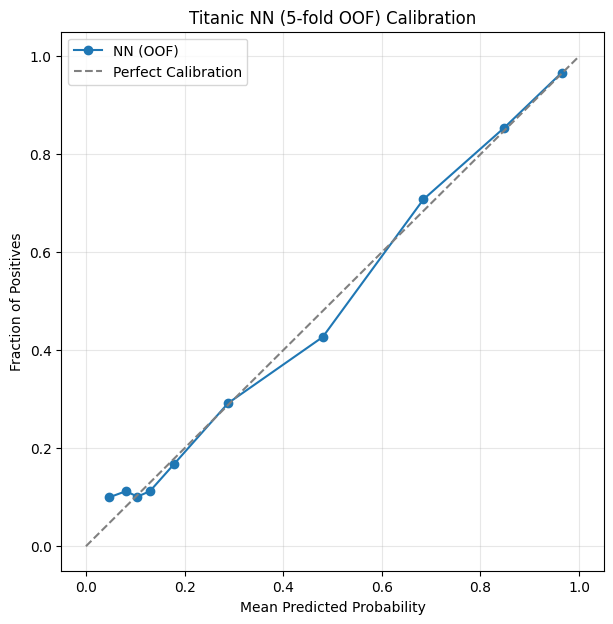

In [91]:
# Results, Summary and Calibration Curve
# ----------------------------
results, summary, oof_p, (mp, fp) = run_nn_cv(
    X_pi, y_data,
    n_splits=5,
    seed=42,
    widths=(32, 64),
    dropout=0.2,
    lr=3e-4,
    label_smoothing=0.0,
    l2=1e-4,
    batch_size=64,
    max_epochs=200,
    patience=10,
    calib_bins=10
)

plot_calibration_curve(mp, fp, title="Titanic NN (5-fold OOF) Calibration", label="NN (OOF)")


# Summary

Cross-validated performance and calibration summary (5-fold OOF)

To reduce the noise introduced by a single train/test split (Titanic is small), the final neural network pipeline was evaluated using 5-fold stratified cross-validation. For each fold, the model was trained on 4/5 of the data and evaluated on the held-out 1/5, then out-of-fold (OOF) predictions were stacked so that every sample received a probability estimate from a model that did not train on that sample.

Fold-level performance (mean ± std across 5 folds)

Across folds, the model achieved:
- ROC-AUC: 0.865 ± 0.023
- Log loss (binary cross-entropy): 0.428 ± 0.036
- Brier score: 0.133 ± 0.013
- Accuracy (threshold = 0.5): 0.827 ± 0.035
- ECE (Expected Calibration Error): 0.078 ± 0.023

These results indicate stable ranking performance (AUC) and good probabilistic accuracy (log loss / Brier) with moderate fold-to-fold variability, as expected for this dataset size.

Out-of-fold (OOF) performance (all samples, predicted out-of-fold)

Stacking the OOF probabilities across all folds yields a single unbiased estimate of generalisation:
- OOF ROC-AUC: 0.8657
- OOF Log loss: 0.4275
- OOF Brier: 0.1326
- OOF Accuracy@0.5: 0.8272
- OOF ECE: 0.0208

Calibration (reliability)

The OOF calibration curve closely follows the ideal diagonal over most of the probability range, indicating that predicted probabilities are largely consistent with observed outcome frequencies. The low OOF ECE (0.0208) supports this visually, suggesting the model’s probabilities are well-calibrated when assessed on out-of-fold predictions (larger effective sample size per bin than any single fold).

Metrics definition (for reference)

Binary cross-entropy (log loss) penalises miscalibrated confident errors:
$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\Big(y_i \log p_i + (1-y_i)\log(1-p_i)\Big)$$
Brier score measures mean squared probability error:
$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$$

Overall, the cross-validated results provide a robust, defensible estimate of model performance and show that the final NN achieves strong discrimination (AUC ≈ 0.866) while maintaining good probabilistic calibration on out-of-fold evaluation.